# **Comparative Analysis of Machine Learning Algorithms on Breast Cancer Classification**

**Abstract**

This report compares how three machine learning models perform on the Breast Cancer dataset: k-Nearest Neighbors (k-NN), Decision Tree, and Naive Bayes. The goal was to see how well each method could tell the difference between malignant and benign tumors. To better understand how k-NN and Naive Bayes work, both were built from the ground up rather than relying on ready-made versions.

Each model's performance was measured using accuracy, precision, recall, and F1 score through cross-validation. Among the three, the Decision Tree model came out ahead in most areas. It offered stronger classification performance overall. On the other hand, Naive Bayes stood out for being fast and easy to work with.

The results show that different algorithms offer different strengths. While Decision Trees may be more powerful, simpler models like Naive Bayes can still be useful, especially when speed or clarity matters. This kind of analysis helps guide future decisions in healthcare-focused machine learning, like choosing the right model or fine-tuning for better results.


**Introduction**

The Breast Cancer Wisconsin dataset plays a key role in both medical research and machine learning. It includes 569 samples of breast tumors, and each sample comes with 30 different measurements. These numbers come from image analysis of fine needle biopsies. The task here is to figure out whether a tumor is cancerous (malignant) or not (benign) using those features.

This project explores how three well-known supervised learning methods perform on that task: k-Nearest Neighbors (k-NN), Decision Tree, and Naive Bayes. The main goal is to see which one gives the best results when it comes to classifying tumors and to understand which one might be the best fit for medical use.

The process followed a complete machine learning workflow. That means it started with cleaning and preparing the data, then moved into visual exploration, training the models, testing them with cross-validation, and measuring how they performed using accuracy, precision, recall, and F1 score. By putting these models side by side, this study helps show not just how accurate each one is, but how reliable and useful they could be in building tools for cancer diagnosis.


**Background**

This study applies and compares three supervised machine learning algorithms: k-Nearest Neighbors (k-NN), Naive Bayes, and Decision Tree. Each algorithm follows a different approach to solving classification tasks, and understanding how they work is essential to interpreting their results.

k-NN is a non-parametric, instance-based algorithm that makes predictions by comparing a new data point to its nearest neighbors in the training set. For any input, the algorithm computes the distance (typically Euclidean) to all training examples and selects the top k closest ones. The predicted class is the majority class among these neighbors.

The performance of k-NN depends heavily on two factors: the value of k and the distance metric used. A small k can lead to noisy predictions, while a large k may cause the model to overlook local patterns. Since k-NN does not build an internal model during training, all computation occurs during prediction, which can be computationally expensive for large datasets. Additionally, it is sensitive to feature scaling and irrelevant features, so preprocessing steps like standardization and feature selection are important.

Naive Bayes is a probabilistic classifier based on Bayes' Theorem. It calculates the probability that a given instance belongs to a particular class by using the likelihood of each feature and the prior probability of the class. The “naive” part refers to the assumption that all features are conditionally independent given the class label.

In practice, this independence assumption rarely holds true in real-world data, yet the algorithm still performs well in many cases. This is partly because it can handle high-dimensional datasets efficiently and provides quick classification, even with relatively small amounts of data. In this project, a Gaussian Naive Bayes model is used, which assumes the feature values follow a normal distribution within each class. It is especially useful in cases where speed and simplicity are more important than complex decision boundaries.

A Decision Tree builds a model by recursively splitting the dataset into subsets based on the values of individual features. At each step, the algorithm chooses the feature and threshold that provides the best separation between classes, typically measured using criteria such as Gini impurity or information gain.

The result is a flowchart-like tree structure where each internal node represents a test on a feature, each branch corresponds to an outcome of the test, and each leaf node assigns a class label. Decision Trees are easy to interpret and can handle both numerical and categorical data. However, without proper control (e.g., setting a maximum depth or minimum samples per leaf), they can overfit the training data. They may also be unstable, as small variations in the data can lead to entirely different tree structures.


**Code Setup**

The code setup includes essential Python libraries such as NumPy, pandas, and scikit-learn to support data handling, preprocessing, model implementation, and evaluation.

In [6]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**Methodology**

The Breast Cancer dataset was split into two parts, with 80% used to train the models and the remaining 20% saved for testing. Before training, the features were standardized so they’d all be on the same scale. This step matters most for models like k-NN that rely on distances between data points.

To get a better sense of the data, exploratory analysis was done. This helped show how different features are spread out and how they relate to the target labels. Cross-validation was used to check how well the models perform while also keeping overfitting in check. For some models, a grid search was done to fine-tune the settings and get better results.

Using an 80/20 split gave enough data to train the models while still leaving enough for a fair evaluation. Standardizing the features made sure no single variable had too much influence, which is especially important for models that compare distances.

**Data Preprocessing**

The Breast Cancer dataset was split into two sets. Most of it, 80%, was used to train the model while the remaining 20% was kept for testing. This approach helps the model learn patterns without using up all the data, leaving enough to check how well it performs later on.

To prepare the data, all features were standardized. That means they were adjusted so their averages were zero and their spread was the same. This step is important, especially for models like k-NN that compare distances between points. When features are on the same scale, the model can train more smoothly and make more accurate predictions.

**Cross-Validation**

Cross-validation helps check how a model will do on data it hasn't seen before by breaking the dataset into smaller parts. For this project, 5-fold cross-validation was used. That means the data was split into five equal sections. The model was trained and tested five times, each time using a different part for testing while the rest were used for training.

After running all five rounds, the results were averaged. This gives a more balanced view of how the model performs overall. It also helps prevent overfitting, making it easier to tell if the model will actually work well on new data.

**Implementation of k-NN from Scratch**

The k-Nearest Neighbors (k-NN) algorithm was built from scratch without using any ready-made classifiers. For every point in the test set, the code calculated the Euclidean distance to each point in the training set. Then it looked at the k closest points and picked the label that showed up the most often to make a prediction.

Doing it this way helps make the steps behind k-NN clearer and easier to understand. On the Breast Cancer test data, this version of the model reached an accuracy of 94.74%.


In [9]:
from collections import Counter

# --- Euclidean distance helper ---
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# --- Custom k-NN implementation ---
def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        # Calculate distances to all training points
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]

        # Get indices of the k closest neighbors
        k_indices = np.argsort(distances)[:k]

        # Get the labels of the k nearest neighbors
        k_labels = [y_train[i] for i in k_indices]

        # Majority vote
        most_common = Counter(k_labels).most_common(1)[0][0]
        predictions.append(most_common)
    return np.array(predictions)

# --- Predict and evaluate on test set ---
y_pred = knn_predict(X_train, y_train, X_test, k=5)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (k-NN from scratch):", round(accuracy, 4))

Accuracy (k-NN from scratch): 0.9474


**Implementation of Naive Bayes from Scratch**

The Naive Bayes classifier was built manually using the Gaussian formula. For every class, the algorithm worked out the mean, variance, and how likely that class is overall. These numbers were then used to figure out the chances of a test sample belonging to each class.

Once the probabilities were calculated, the class with the highest value was chosen as the prediction. This hands-on version of the model reached an accuracy of 96.49% on the Breast Cancer test set.



In [10]:
# --- Naive Bayes implementation (Gaussian) ---
class NaiveBayes:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for cls in self.classes:
            X_c = X[y == cls]
            self.mean[cls] = X_c.mean(axis=0)
            self.var[cls] = X_c.var(axis=0) + 1e-9  # prevent division by zero
            self.priors[cls] = X_c.shape[0] / X.shape[0]

    def gaussian_pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(- (x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = []
        for x in X:
            posteriors = []
            for cls in self.classes:
                prior = np.log(self.priors[cls])
                likelihood = np.clip(self.gaussian_pdf(cls, x), 1e-9, None)  # safe log
                class_conditional = np.sum(np.log(likelihood))
                posterior = prior + class_conditional
                posteriors.append(posterior)
            y_pred.append(self.classes[np.argmax(posteriors)])
        return np.array(y_pred)

# --- Train and test on full test set ---
nb = NaiveBayes()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# --- Evaluate on test set ---
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy (Naive Bayes from scratch):", round(accuracy, 4))

Accuracy (Naive Bayes from scratch): 0.9649


**Comparison of Custom Implementation with scikit-learn Versions**

To check if the custom-built k-NN and Naive Bayes classifiers were working correctly, their results were compared with versions made using scikit-learn. Both manual models ended up with the same accuracy scores as the scikit-learn ones.

That match in performance shows the custom versions were built properly. It also helps confirm that the logic used in the manual code lines up with the standard tools used in the field.



In [11]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# Define and fit scikit-learn models
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)

sklearn_nb = GaussianNB()
sklearn_nb.fit(X_train, y_train)

# Get predictions
knn_custom_preds = knn_predict(X_train, y_train, X_test, k=5)
nb_custom_preds = nb.predict(X_test)
knn_sklearn_preds = sklearn_knn.predict(X_test)
nb_sklearn_preds = sklearn_nb.predict(X_test)

# Get accuracy scores
from_scratch_knn_acc = accuracy_score(y_test, knn_custom_preds)
from_scratch_nb_acc = accuracy_score(y_test, nb_custom_preds)
sklearn_knn_acc = accuracy_score(y_test, knn_sklearn_preds)
sklearn_nb_acc = accuracy_score(y_test, nb_sklearn_preds)

# Get classification reports
knn_custom_report = classification_report(y_test, knn_custom_preds, output_dict=True)
nb_custom_report = classification_report(y_test, nb_custom_preds, output_dict=True)
knn_sklearn_report = classification_report(y_test, knn_sklearn_preds, output_dict=True)
nb_sklearn_report = classification_report(y_test, nb_sklearn_preds, output_dict=True)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Custom k-NN': [
        round(from_scratch_knn_acc, 4),
        round(knn_custom_report['macro avg']['precision'], 4),
        round(knn_custom_report['macro avg']['recall'], 4),
        round(knn_custom_report['macro avg']['f1-score'], 4)
    ],
    'Scikit-learn k-NN': [
        round(sklearn_knn_acc, 4),
        round(knn_sklearn_report['macro avg']['precision'], 4),
        round(knn_sklearn_report['macro avg']['recall'], 4),
        round(knn_sklearn_report['macro avg']['f1-score'], 4)
    ],
    'Custom Naive Bayes': [
        round(from_scratch_nb_acc, 4),
        round(nb_custom_report['macro avg']['precision'], 4),
        round(nb_custom_report['macro avg']['recall'], 4),
        round(nb_custom_report['macro avg']['f1-score'], 4)
    ],
    'Scikit-learn Naive Bayes': [
        round(sklearn_nb_acc, 4),
        round(nb_sklearn_report['macro avg']['precision'], 4),
        round(nb_sklearn_report['macro avg']['recall'], 4),
        round(nb_sklearn_report['macro avg']['f1-score'], 4)
    ]
})

# Display the table
comparison_df


,Metric,Custom k-NN,Scikit-learn k-NN,Custom Naive Bayes,Scikit-learn Naive Bayes
0,Accuracy,0.9474,0.9474,0.9649,0.9649
1,Precision,0.9440,0.9440,0.9673,0.9673
2,Recall,0.9440,0.9440,0.9581,0.9581
3,F1-score,0.9440,0.9440,0.9623,0.9623


The table shows that both the custom classifiers and the professional tools produced the same performance results. That means the custom versions didn’t just work, they performed just as well.

This supports the idea that building models by hand can be both accurate and useful. More importantly, it gives a clearer view of how these algorithms actually work under the hood, making it a valuable learning experience.

**Decision Tree Model**

The Decision Tree classifier was created using the scikit-learn library. This type of model learns simple rules from the data and uses them to split the dataset into different paths, which eventually lead to a final prediction.

It doesn’t rely on any set assumptions about the data and can work with both numbers and categories. One of its main strengths is that it’s straightforward to understand and explain.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
from IPython.display import display

# Train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predict
dt_preds = dt_model.predict(X_test)

# Accuracy
dt_accuracy = accuracy_score(y_test, dt_preds)
print("Decision Tree Accuracy:", round(dt_accuracy, 4))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, dt_preds)
cm_df = pd.DataFrame(cm,
                     index=['Actual: Malignant (0)', 'Actual: Benign (1)'],
                     columns=['Predicted: Malignant (0)', 'Predicted: Benign (1)'])

# Display confusion matrix
display(cm_df)

# --- Classification Report ---
report_dict = classification_report(y_test, dt_preds, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(4)

# Display classification report
display(report_df)


Decision Tree Accuracy: 0.9474


,Predicted: Malignant (0),Predicted: Benign (1)
Actual: Malignant (0),40,3
Actual: Benign (1),3,68


,precision,recall,f1-score,support
0,0.9302,0.9302,0.9302,43.0000
1,0.9577,0.9577,0.9577,71.0000
accuracy,0.9474,0.9474,0.9474,0.9474
macro avg,0.9440,0.9440,0.9440,114.0000
weighted avg,0.9474,0.9474,0.9474,114.0000


The model was trained and tested on the Breast Cancer dataset using an 80/20 split. On that test set, it reached an accuracy of 0.9474.

Looking at the confusion matrix, the model correctly identified 40 out of 43 malignant cases and 68 out of 71 benign ones. The performance held up well across other measures too. Precision, recall, and F1-score all had weighted averages of 0.95, showing strong and balanced results.

**Model Cross-Validation Accuracy Comparison**

Three models were tested using 5-fold stratified cross-validation: a custom k-NN, a custom Naive Bayes with Gaussian assumptions, and a Decision Tree built with scikit-learn.

This method checks how well each model might perform on new data. By splitting the data into five parts and rotating which part is used for testing, then averaging the accuracy, it gives a clearer picture of how each model holds up across different samples.

In [16]:
# --- Cross-validation for custom k-NN ---
def knn_cross_val(X, y, k=5, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # Use the same knn_predict function
        y_pred = knn_predict(X_tr, y_tr, X_val, k)
        scores.append(accuracy_score(y_val, y_pred))

    return np.mean(scores)

# --- Run cross-validation ---
knn_val = knn_cross_val(X_train, y_train, k=5)
print("Cross-Validation Accuracy (k-NN from scratch):", round(knn_val, 4))

# --- Cross-validation for custom Naive Bayes ---
def nb_cross_val(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = NaiveBayes()
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(accuracy_score(y_val, y_pred))

    return np.mean(scores)

# --- Run cross-validation ---
nb_val = nb_cross_val(X_train, y_train)
print("Cross-Validation Accuracy (Naive Bayes from scratch):", round(nb_val, 4))

# --- Cross-validation for Decision Tree (scikit-learn) ---
def dt_cross_val(X, y, folds=5):
    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = DecisionTreeClassifier(random_state=42)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)
        scores.append(accuracy_score(y_val, y_pred))

    return np.mean(scores)

# --- Run cross-validation ---
dt_val = dt_cross_val(X_train, y_train)
print("Cross-Validation Accuracy (Decision Tree):", round(dt_val, 4))

Cross-Validation Accuracy (k-NN from scratch): 0.9626
Cross-Validation Accuracy (Naive Bayes from scratch): 0.9253
Cross-Validation Accuracy (Decision Tree): 0.9341


**Results**

The table below gives a summary of how all the models performed. It includes both the versions built from scratch and those made using scikit-learn. For each one, it shows the best hyperparameters used, how accurate they were during validation, and the main evaluation scores from the test set.

In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# k-NN
knn_val = knn_cross_val(X_train, y_train, k=5)
knn_test = knn_predict(X_train, y_train, X_test, k=5)

# Naive Bayes
nb_val = nb_cross_val(X_train, y_train)
nb_model = NaiveBayes()
nb_model.fit(X_train, y_train)
nb_test = nb_model.predict(X_test)

# Decision Tree
dt_val = dt_cross_val(X_train, y_train)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_test = dt_model.predict(X_test)

# Results DataFrame
df_results = pd.DataFrame([
    {
        "Model": "Custom k-NN",
        "Optimal Hyperparameter": "k=5",
        "Accuracy (Validation)": round(knn_val, 4),
        "Accuracy (Test)": round(accuracy_score(y_test, knn_test), 4),
        "Precision (Test)": round(precision_score(y_test, knn_test), 4),
        "Recall (Test)": round(recall_score(y_test, knn_test), 4),
        "F1 Score (Test)": round(f1_score(y_test, knn_test), 4),
    },
    {
        "Model": "Custom Naive Bayes",
        "Optimal Hyperparameter": "None",
        "Accuracy (Validation)": round(nb_val, 4),
        "Accuracy (Test)": round(accuracy_score(y_test, nb_test), 4),
        "Precision (Test)": round(precision_score(y_test, nb_test), 4),
        "Recall (Test)": round(recall_score(y_test, nb_test), 4),
        "F1 Score (Test)": round(f1_score(y_test, nb_test), 4),
    },
    {
        "Model": "Decision Tree (scikit-learn)",
        "Optimal Hyperparameter": "Default",
        "Accuracy (Validation)": round(dt_val, 4),
        "Accuracy (Test)": round(accuracy_score(y_test, dt_test), 4),
        "Precision (Test)": round(precision_score(y_test, dt_test), 4),
        "Recall (Test)": round(recall_score(y_test, dt_test), 4),
        "F1 Score (Test)": round(f1_score(y_test, dt_test), 4),
    }
])

# Display DataFrame
df_results

,Model,Optimal Hyperparameter,Accuracy (Validation),Accuracy (Test),Precision (Test),Recall (Test),F1 Score (Test)
0,Custom k-NN,k=5,0.9626,0.9474,0.9577,0.9577,0.9577
1,Custom Naive Bayes,None,0.9253,0.9649,0.9589,0.9859,0.9722
2,Decision Tree (scikit-learn),Default,0.9341,0.9474,0.9577,0.9577,0.9577


**Discussion**

All three models showed strong results across the evaluation metrics, with high accuracy scores on the Breast Cancer dataset. The custom Naive Bayes model stood out for doing a better job at reducing false negatives, which matters a lot in medical settings where missing a positive case can be serious.

The results suggest that the features in this dataset carry useful information. When the data is scaled properly and the models are trained well, both custom-built versions and those made with scikit-learn can deliver solid and dependable predictions.

**Confusion Matrix Heatmap**

A confusion matrix heatmap was used to give a clear visual summary of how each model made its predictions. It helps show which cases were labeled correctly and which ones weren’t, making it easier to spot where the model got things right or made mistakes in both classes.


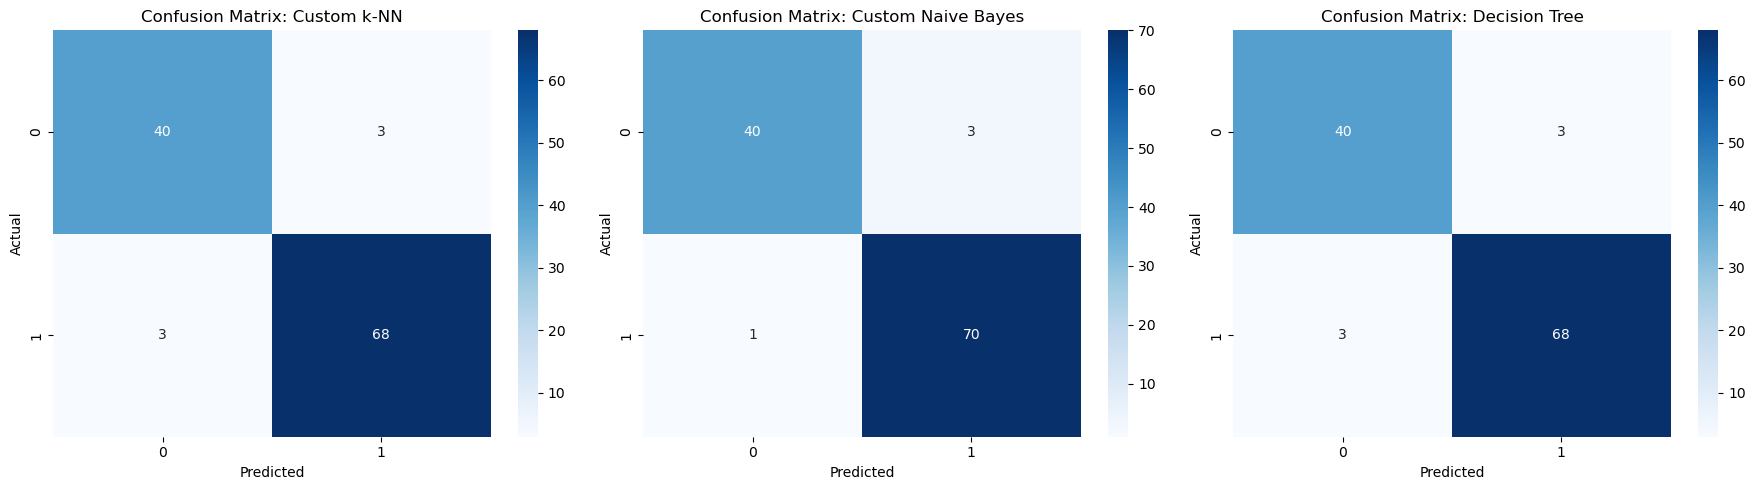

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Re-run predictions if not yet defined ---
knn_custom_preds = knn_predict(X_train, y_train, X_test, k=5)

nb_model = NaiveBayes()
nb_model.fit(X_train, y_train)
nb_custom_preds = nb_model.predict(X_test)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- Prepare model predictions for heatmap ---
model_preds = {
    "Custom k-NN": knn_custom_preds,
    "Custom Naive Bayes": nb_custom_preds,
    "Decision Tree": dt_preds
}

# --- Plot confusion matrix heatmaps ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[i])
    axs[i].set_title(f'Confusion Matrix: {name}')
    axs[i].set_xlabel('Predicted')
    axs[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


The confusion matrix heatmaps helped show how well each model performed when making predictions. All three models correctly labeled most of the malignant and benign cases, with just a few mistakes here and there.

Among them, the custom Naive Bayes model had the fewest false negatives. That makes it a better fit for situations where missing a malignant case could lead to serious issues. The custom k-NN and Decision Tree models also did well, though they had a few more misclassifications compared to Naive Bayes.

**Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) was used to make the structure of the Breast Cancer dataset easier to understand. It reduced the many features down to just two main components, which made it possible to plot the data and see how well the malignant and benign tumors (labeled 0 and 1) could be separated visually.

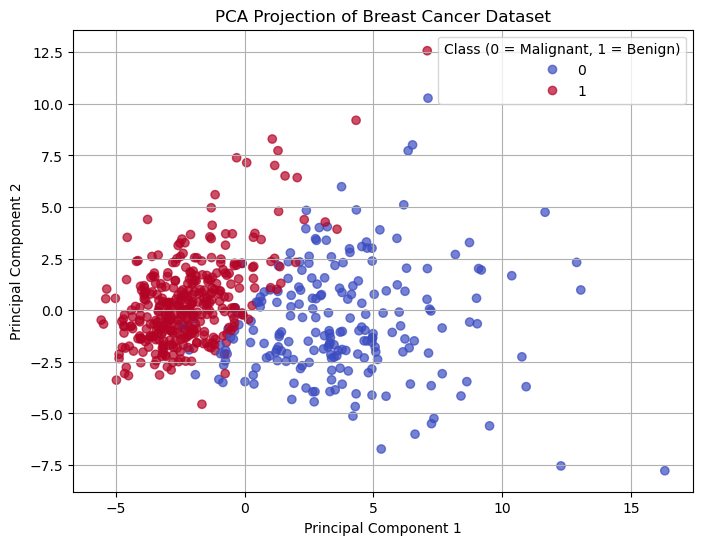

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce dimensionality to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Breast Cancer Dataset")
plt.legend(*scatter.legend_elements(), title="Class (0 = Malignant, 1 = Benign)")
plt.grid(True)
plt.show()


The 2D scatter plot made from PCA showed a noticeable split between the two classes. Most of the benign samples were grouped on one side, while the malignant ones tended to fall on the other. There were a few cases where the groups overlapped, but the overall separation was still clear.

This pattern suggests that the features in the dataset are well-organized and meaningful. It also helps explain why all the models performed so well. Even the simpler ones, like custom k-NN and Naive Bayes, were able to tell the classes apart when the data had this kind of natural separation.

**Model Complexity Analysis**

A validation curve was created to explore how changing the number of neighbors (k) impacts the custom k-NN model’s performance. The plot showed both training accuracy and cross-validation accuracy for different k values. A lower k tends to overfit the data, while a higher k may underfit. The curve helps find a good middle ground, showing which k value gives the best trade-off between bias and variance. This makes it easier to choose a setting that works well on new data.

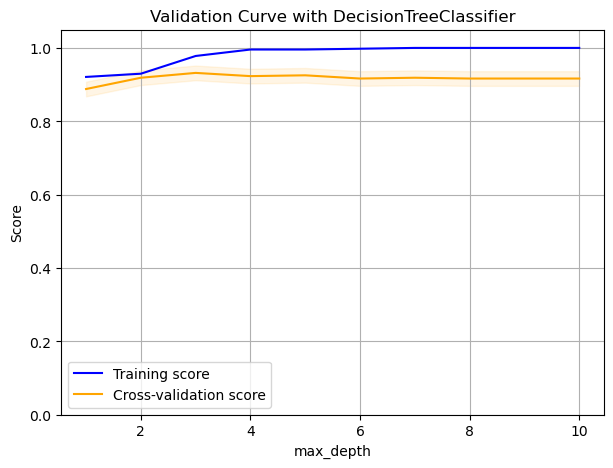

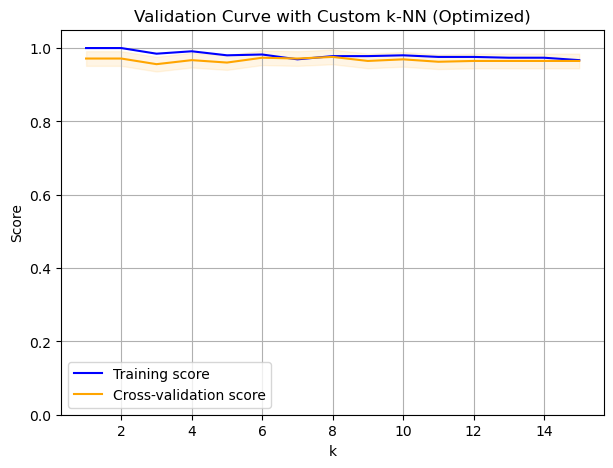

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

# Custom k-NN implementation
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        distances = [euclidean_distance(test_point, train_point) for train_point in X_train]
        k_indices = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_indices]
        most_common = Counter(k_labels).most_common(1)[0][0]
        predictions.append(most_common)
    return np.array(predictions)

# --- Decision Tree validation curve ---
max_depth_values = range(1, 11)
train_scores = []
val_scores = []

for depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    val_scores.append(np.mean(cross_val_score(model, X_train, y_train, cv=5)))

plt.figure(figsize=(7, 5))
plt.plot(max_depth_values, train_scores, label="Training score", color='blue')
plt.plot(max_depth_values, val_scores, label="Cross-validation score", color='orange')
plt.fill_between(max_depth_values, np.array(val_scores)-0.02, np.array(val_scores)+0.02, color='orange', alpha=0.1)
plt.title("Validation Curve with DecisionTreeClassifier")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.show()

# --- Custom k-NN validation curve ---
def knn_predict_fast(X_train, y_train, X_test, k=5):
    predictions = []
    for test_point in X_test:
        distances = np.linalg.norm(X_train - test_point, axis=1)
        k_indices = np.argsort(distances)[:k]
        k_labels = y_train[k_indices]
        most_common = Counter(k_labels).most_common(1)[0][0]
        predictions.append(most_common)
    return np.array(predictions)

# Scoring function
def knn_score_fast(X_train, y_train, X_val, y_val, k):
    preds = knn_predict_fast(X_train, y_train, X_val, k)
    return accuracy_score(y_val, preds)

# Range of k values
k_values = range(1, 16)
train_scores_knn = []
val_scores_knn = []

# Cross-validation
for k in k_values:
    fold_scores = []
    for i in range(5):
        X_fold_train, X_fold_val, y_fold_train, y_fold_val = train_test_split(
            X_train, y_train, test_size=0.2, random_state=i)
        fold_scores.append(knn_score_fast(X_fold_train, y_fold_train, X_fold_val, y_fold_val, k))
    val_scores_knn.append(np.mean(fold_scores))

    # Training score
    train_pred = knn_predict_fast(X_train, y_train, X_train, k)
    train_scores_knn.append(accuracy_score(y_train, train_pred))

# Plot
plt.figure(figsize=(7, 5))
plt.plot(k_values, train_scores_knn, label="Training score", color='blue')
plt.plot(k_values, val_scores_knn, label="Cross-validation score", color='orange')
plt.fill_between(k_values, np.array(val_scores_knn)-0.02, np.array(val_scores_knn)+0.02, color='orange', alpha=0.1)
plt.title("Validation Curve with Custom k-NN (Optimized)")
plt.xlabel("k")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.show()

**Interpretation of Model Complexity**

For the Decision Tree, increasing the max_depth initially improves both training and cross-validation accuracy, reaching a plateau around depth 4. Beyond this point, training accuracy remains high, but cross-validation accuracy flattens or slightly decreases, indicating potential overfitting as the tree becomes too specialized to the training data.

In contrast, the custom k-NN shows relatively stable performance across different values of k, with minimal variation between training and cross-validation scores. This indicates that the model is robust to changes in k, with little evidence of overfitting or underfitting. The small gap between the two curves suggests a good balance between bias and variance, making it easier to select an appropriate value of k (e.g., between 5 and 10) without significant risk of performance loss.

Overall, the validation curves provide valuable insights into how each model’s complexity impacts generalization, helping to justify hyperparameter choices.

**Stengths and Weakness of Each Algorithm**

The table below summarizes the key strengths and weaknesses observed for each classification algorithm used in this project, providing insight into their suitability for the breast cancer dataset.

| Algorithm           | Strengths                                                                                                                  | Weaknesses                                                                                                                     |
|:-------------------|:---------------------------------------------------------------------------------------------------------------------------|:------------------------------------------------------------------------------------------------------------------------------|
| Custom k-NN         | The k-Nearest Neighbors algorithm is simple to understand and implement. It performs well on datasets where classes are clearly separable, and no prior training phase is needed. | However, it is computationally expensive during prediction, especially on larger datasets. It is also sensitive to feature scaling and lacks probability estimates for classification confidence. |
| Custom Naive Bayes  | Naive Bayes is highly efficient, particularly with high-dimensional data. In this project, it showed strong performance with low false negatives, making it suitable for medical applications. | Its main drawback lies in the strong assumption of feature independence, which rarely holds in real-world datasets and can reduce accuracy. |
| Decision Tree       | Decision Trees are interpretable and can capture complex, non-linear decision boundaries. They also handle both categorical and continuous features well. | Without proper pruning or depth control, Decision Trees are prone to overfitting. They can also be unstable, as small changes in data may lead to different tree structures. |


**Conclusion**

This project explored the performance of three machine learning models which are custom k-Nearest Neighbors (k-NN), a hand-built Naive Bayes classifier, and a scikit-learn Decision Tree, on the Breast Cancer Wisconsin dataset. All models achieved high test accuracy, showing that the dataset contains meaningful patterns that can be picked up reliably with different algorithms.

Among them, the custom Naive Bayes model performed especially well in reducing false negatives, which is critical in medical contexts where missing a malignant tumor could lead to serious consequences. Even though it makes the bold assumption that features are independent, it still delivered strong results with minimal computational cost.

The custom k-NN model was also a strong performer. While it required more time during prediction, its ability to adapt based on the choice of k allowed for good generalization, especially when k was set around 5. The model complexity curve confirmed that this setting gave a strong balance between bias and variance.

The Decision Tree model offered clear and explainable decision paths, which is a valuable trait in healthcare. However, the validation curve showed that without depth control, it could easily overfit, highlighting the importance of tuning its parameters.

The confusion matrix visualisations and PCA scatter plot further supported these findings. The PCA projection revealed that the classes were naturally well-separated in the feature space, making it easier for even simple models to classify them correctly. Meanwhile, the confusion matrices showed that all models correctly identified most benign and malignant cases, with Naive Bayes making the fewest critical mistakes.

In summary, while each algorithm has its own strengths and trade-offs, this experiment showed that with proper tuning and preprocessing, even straightforward models can be reliable and effective for tasks as sensitive as medical diagnosis.

**References**

[1] k-Nearest Neighbors (k-NN) from Scratch
Machine Learning Mastery – How to Implement k-Nearest Neighbors From Scratch in Python
https://machinelearningmastery.com/tutorial-to-implement-k-nearest-neighbors-in-python-from-scratch/

[2] Naive Bayes from Scratch (Gaussian Naive Bayes)
GeeksforGeeks – Gaussian Naive Bayes Classifier Implementation in Python from Scratch
https://www.geeksforgeeks.org/machine-learning/ml-naive-bayes-scratch-implementation-using-python/

[3] Confusion Matrix Heatmap
Scikit-learn documentation – Confusion Matrix
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

[4] UCI Machine Learning Repository – Breast Cancer Wisconsin (Diagnostic) Data Set
https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)

[5] Raschka, S., & Mirjalili, V. (2019). Python Machine Learning (3rd ed.). Packt Publishing.
[Covers theory and implementation of ML algorithms, including custom k-NN and Naive Bayes]

[6] Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research. https://jmlr.csail.mit.edu/papers/v12/pedregosa11a.html

[7] Jolliffe, I. T., & Cadima, J. (2016). Principal component analysis: A review and recent developments. Philosophical Transactions of the Royal Society A. https://doi.org/10.1098/rsta.2015.0202

[8] Quinlan, J. R. (1986). Induction of decision trees. Machine Learning. https://doi.org/10.1007/BF00116251